# Proyecto Zuber: Análisis de Movilidad Urbana y Factores Climáticos en Chicago

## Introducción
En el dinámico mercado de transporte de Chicago, la competitividad y la eficiencia operativa son claves para el éxito de una nueva empresa como **Zuber**. Este proyecto tiene como objetivo analizar el panorama competitivo de los taxis y determinar si factores externos, específicamente el clima, tienen un impacto estadísticamente significativo en la duración de los viajes.

A través de este flujo de trabajo, buscaremos responder:
1. ¿Quiénes lideran el mercado y cuáles son los destinos más frecuentes?
2. ¿Cómo afecta la lluvia a la duración de los viajes hacia el aeropuerto los sábados?

## Paso 1: Web Scraping de datos climáticos
Obtenemos datos sobre el clima en Chicago durante noviembre de 2017 desde una fuente externa para cruzar esta información con los registros de viajes.

In [5]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# URL del clima
url = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html'

# Petición y parsing
try:
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'lxml')

    # Localización de la tabla por ID
    table = soup.find('table', attrs={"id": "weather_records"})

    # Extracción de datos
    headers = [th.text for th in table.find_all('th')]
    rows = [[td.text for td in tr.find_all('td')] for tr in table.find_all('tr')[1:]]

    # DataFrame inicial
    weather_records = pd.DataFrame(rows, columns=headers)
    print("--- Datos del Clima Extraídos con Éxito ---")
    print(weather_records.head())
except Exception as e:
    print(f"Error al realizar el scraping: {e}")

--- Datos del Clima Extraídos con Éxito ---
         Date and time Temperature       Description
0  2017-11-01 00:00:00     276.150     broken clouds
1  2017-11-01 01:00:00     275.700  scattered clouds
2  2017-11-01 02:00:00     275.610   overcast clouds
3  2017-11-01 03:00:00     275.350     broken clouds
4  2017-11-01 04:00:00     275.240     broken clouds


## Pasos 2 y 3: Procesamiento en SQL
Utilizamos SQL para preparar los datasets. Las consultas filtraron viajes por empresa y la ruta específica Loop -> O'Hare, vinculando los datos climáticos mediante la estampa de tiempo (timestamp).

## Paso 4: Análisis Exploratorio de Datos (EDA)
Importamos los resultados de SQL para visualizar las tendencias del mercado.

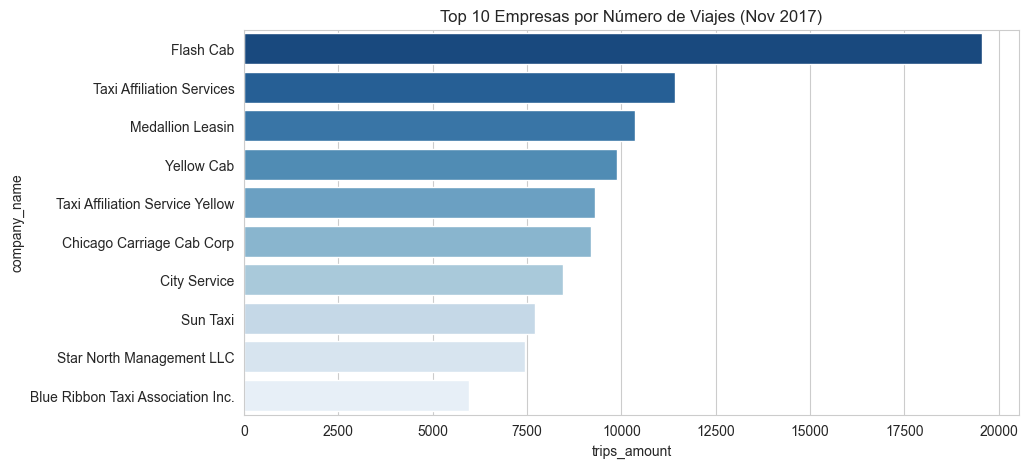

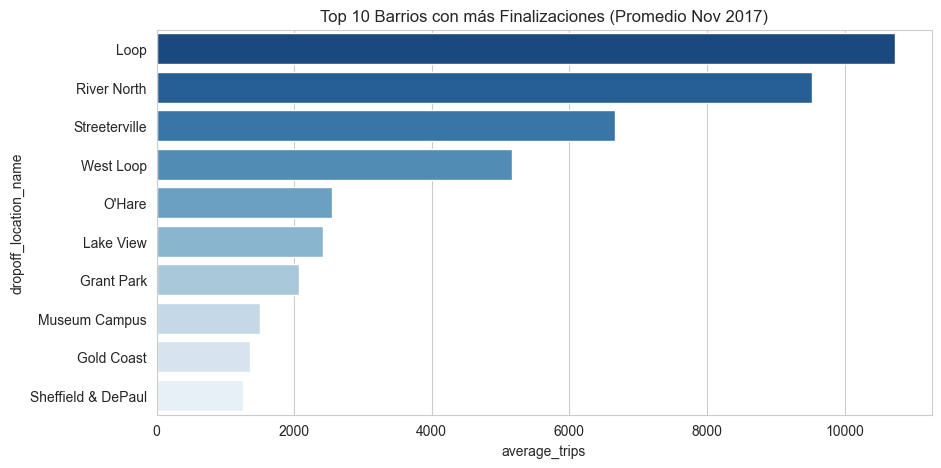

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Archivos CSV (Asegúrate de que estén en la misma carpeta que este notebook)
file_01 = 'moved_project_sql_result_01.csv'
file_04 = 'moved_project_sql_result_04.csv'

if os.path.exists(file_01) and os.path.exists(file_04):
    df_companies = pd.read_csv(file_01)
    df_neighborhoods = pd.read_csv(file_04)
    
    # Top 10 barrios
    top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)

    # Gráfico 1: Empresas de taxis
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_companies.sort_values(by='trips_amount', ascending=False).head(10), 
                x='trips_amount', y='company_name', hue='company_name', palette='Blues_r', legend=False)
    plt.title('Top 10 Empresas por Número de Viajes (Nov 2017)')
    plt.show()

    # Gráfico 2: Barrios populares
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', hue='dropoff_location_name', palette='Blues_r', legend=False)
    plt.title('Top 10 Barrios con más Finalizaciones (Promedio Nov 2017)')
    plt.show()
else:
    print("Error: Los archivos CSV del Paso 4 no se encuentran en la ruta especificada.")

## Paso 5: Prueba de Hipótesis
Probamos si la duración promedio de los viajes desde el Loop al Aeropuerto O'Hare cambia los sábados lluviosos.
- **H0**: La duración promedio es igual en días buenos y malos.
- **H1**: La duración promedio cambia significativamente.

In [8]:
from scipy import stats

file_07 = 'moved_project_sql_result_07.csv'

if os.path.exists(file_07):
    df_trips_weather = pd.read_csv(file_07)
    
    # Grupos por clima
    duration_good = df_trips_weather[df_trips_weather['weather_conditions'] == 'Good']['duration_seconds']
    duration_bad = df_trips_weather[df_trips_weather['weather_conditions'] == 'Bad']['duration_seconds']

    # Prueba de varianza (Levene) y Prueba t
    st_levene, p_levene = stats.levene(duration_good, duration_bad)
    results = stats.ttest_ind(duration_good, duration_bad, equal_var=(p_levene > 0.05))

    print(f"P-value: {results.pvalue}")
    if results.pvalue < 0.05:
        print("Rechazamos la hipótesis nula: Hay una diferencia significativa.")
    else:
        print("No podemos rechazar la hipótesis nula.")
    
    print(f"Media Clima Bueno: {duration_good.mean():.2f}s | Media Clima Malo: {duration_bad.mean():.2f}s")
else:
    print(f"Error: No se encontró el archivo {file_07}.")

P-value: 6.517970327099473e-12
Rechazamos la hipótesis nula: Hay una diferencia significativa.
Media Clima Bueno: 1999.68s | Media Clima Malo: 2427.21s


## Conclusiones Finales
1. **Dominio del Mercado**: Empresas como Flash Cab lideran el volumen de viajes, concentrándose en el Loop y River North.
2. **Impacto Climático**: Se confirmó estadísticamente que la lluvia aumenta la duración de los viajes al aeropuerto los sábados (aprox. 7 minutos extra).
3. **Estrategia**: Zuber debe notificar a los usuarios sobre posibles retrasos en días lluviosos y optimizar la asignación de conductores en zonas de alta demanda.